# 04 — Demand Estimation

Builds Bᵢ (base demand), then the equity-adjusted Dᵢ(α) with total-demand normalisation,
for the four α scenarios A/B/C/D (α = 0, 0.1, 0.3, 0.5). Consumes 03_EDA's on-street-filtered
eⱼ/ūᵢ/has_evse_i -- no changes needed here versus the earlier (unfiltered) run other than
the input numbers themselves.

## 0. Setup and reload cleaned data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
seff_london   = pd.read_csv(os.path.join(BASE, "05_processed/seff_london.csv"))

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, seff_london: {seff_london.shape}")

Datasets reloaded.
census_london: (4994, 8), imd_london: (4994, 10), seff_london: (4994, 7)


## 1. Base demand Bᵢ = (Hᵢ × Cᵢ) × Pd × Ppub × Uᵢ

In [2]:
Pd = 4.3 / 14
Ppub = 1.8 / 4.4
print(f"Pd   = 4.3 / 14  = {Pd:.6f}")
print(f"Ppub = 1.8 / 4.4 = {Ppub:.6f}")

Pd   = 4.3 / 14  = 0.307143
Ppub = 1.8 / 4.4 = 0.409091


In [3]:
demand_base = census_london[["lsoa_code", "lsoa_name", "Hi", "Ci"]].merge(
    seff_london[["lsoa_code", "ej", "seff", "ubar_i", "has_evse_i"]], on="lsoa_code", how="left"
)
demand_base["Ui"] = np.where(demand_base["has_evse_i"], 1 + demand_base["ubar_i"], 1.0)

print("Ui summary:")
print(demand_base["Ui"].describe())
print(f"\nLSOAs with Ui = 1 exactly: {(demand_base['Ui'] == 1.0).sum()}")
assert demand_base["Ui"].isna().sum() == 0

Ui summary:
count    4994.000000
mean        1.061290
std         0.140770
min         1.000000
25%         1.000000
50%         1.000000
75%         1.045365
max         1.962401
Name: Ui, dtype: float64

LSOAs with Ui = 1 exactly: 2705


In [4]:
demand_base["Vi"] = demand_base["Hi"] * demand_base["Ci"]
demand_base["Bi"] = demand_base["Vi"] * Pd * Ppub * demand_base["Ui"]

print("=== Bᵢ summary ===")
print(demand_base["Bi"].describe())

=== Bᵢ summary ===
count    4994.000000
mean       72.009225
std        27.770552
min         8.669805
25%        49.801842
50%        70.721343
75%        92.741640
max       184.871081
Name: Bi, dtype: float64


## 2. Equity-adjusted demand Dᵢ(α), normalised so total demand is constant across scenarios

In [5]:
demand_full = demand_base.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")
assert demand_full["income_score"].isna().sum() == 0

SCENARIOS = {"A": 0.0, "B": 0.1, "C": 0.3, "D": 0.5}

def demand_for_alpha(Bi, IMDi, alpha):
    raw = Bi * (1 + alpha * IMDi)
    norm_factor = raw.sum() / Bi.sum()
    return raw / norm_factor

Bi = demand_full["Bi"].to_numpy()
IMDi = demand_full["income_score"].to_numpy()

for label, alpha in SCENARIOS.items():
    demand_full[f"D_{label}"] = demand_for_alpha(Bi, IMDi, alpha)

bi_total = demand_full["Bi"].sum()
print("=== Total demand by scenario (should all match Sigma Bi) ===")
print(f"Sigma Bi: {bi_total:,.2f}")
for label, alpha in SCENARIOS.items():
    total = demand_full[f"D_{label}"].sum()
    print(f"Sigma D_{label} (alpha={alpha}): {total:,.2f}  (matches Bi: {np.isclose(total, bi_total)})")
print()
print("alpha=0 (Scenario A) reproduces Bi exactly:", np.allclose(demand_full["D_A"], demand_full["Bi"]))

=== Total demand by scenario (should all match Sigma Bi) ===
Sigma Bi: 359,614.07
Sigma D_A (alpha=0.0): 359,614.07  (matches Bi: True)
Sigma D_B (alpha=0.1): 359,614.07  (matches Bi: True)
Sigma D_C (alpha=0.3): 359,614.07  (matches Bi: True)
Sigma D_D (alpha=0.5): 359,614.07  (matches Bi: True)

alpha=0 (Scenario A) reproduces Bi exactly: True


## 3. Distribution comparison and save

In [6]:
scenario_cols = [f"D_{label}" for label in ["A","B","C","D"]]
print(demand_full[scenario_cols].describe())

output_path = os.path.join(BASE, "05_processed/demand_london.csv")
demand_full.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

               D_A          D_B          D_C          D_D
count  4994.000000  4994.000000  4994.000000  4994.000000
mean     72.009225    72.009225    72.009225    72.009225
std      27.770552    27.371052    26.713717    26.218205
min       8.669805     8.521745     8.246132     7.994845
25%      49.801842    50.146257    50.731630    51.403797
50%      70.721343    70.967508    71.356373    71.788479
75%      92.741640    92.408673    91.904766    91.469243
max     184.871081   185.835326   190.792502   195.312158

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv


## 4. Sanity check: does higher alpha shift demand toward more deprived LSOAs?

In [7]:
from scipy.stats import pearsonr
print("=== Pearson r: D_scenario vs income_score ===")
for label, alpha in SCENARIOS.items():
    r, p = pearsonr(demand_full[f"D_{label}"], demand_full["income_score"])
    print(f"Scenario {label} (alpha={alpha}): r = {r:.4f}, p = {p:.4g}")

=== Pearson r: D_scenario vs income_score ===
Scenario A (alpha=0.0): r = -0.4021, p = 1.9e-193
Scenario B (alpha=0.1): r = -0.3737, p = 2.917e-165
Scenario C (alpha=0.3): r = -0.3174, p = 2.659e-117
Scenario D (alpha=0.5): r = -0.2626, p = 1.417e-79


## 5. Demand maps — Scenario A (baseline) vs Scenario C (primary)

In [8]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

LSOA boundaries matched: 4994 / 4994 expected


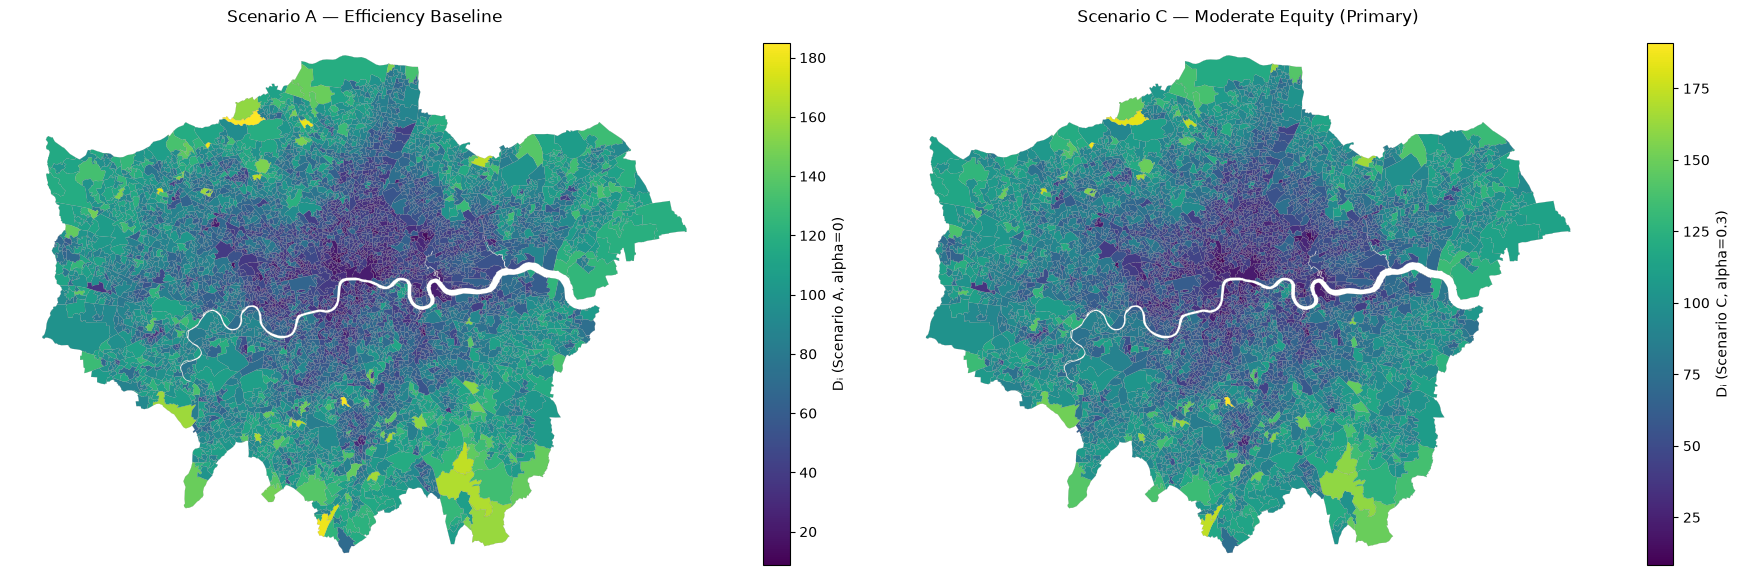

In [9]:
demand_map = lsoa_london.merge(demand_full[["lsoa_code", "D_A", "D_C"]], on="lsoa_code", how="left")
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
demand_map.plot(column="D_A", cmap="viridis", linewidth=0.1, edgecolor="grey", legend=True,
                 ax=axes[0], legend_kwds={"label": "Dᵢ (Scenario A, alpha=0)", "shrink": 0.6})
axes[0].set_title("Scenario A — Efficiency Baseline"); axes[0].axis("off")
demand_map.plot(column="D_C", cmap="viridis", linewidth=0.1, edgecolor="grey", legend=True,
                 ax=axes[1], legend_kwds={"label": "Dᵢ (Scenario C, alpha=0.3)", "shrink": 0.6})
axes[1].set_title("Scenario C — Moderate Equity (Primary)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenarios_A_C.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Update pipeline_summary.csv

In [10]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
item = "Demand Di computed (4 scenarios A-D)"
value = f"Done — {len(demand_full)} LSOAs, total demand = {demand_full['Bi'].sum():,.1f}"
if (pipeline_summary["Item"] == item).any():
    pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
else:
    pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)
pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                                   Item                                                   Count
                          LSOAs loaded (Greater London)                                                    4994
      Household total (Hi sum, validated vs gor:London)                                                 3423845
Total EVSE locations (OpenStreetEV_GLA, all categories)                                                   23015
            On-street EVSE locations (OpenStreetEV_GLA)                                                   21366
          Session records (join_august2025, post-clean)                                                   63105
          Unique EVSEs with >=1 session (ur_j computed)                                                   10465
              eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level) Done (on-street only) — 3157 LSOAs with has_evse_i=True
                 EVSEs matched to LSOA via spatial join                                                 